<a href="https://colab.research.google.com/github/enslern/The-AI-engineer-course-2026-Complete-AI-bootcamp/blob/main/question_and_answer_models_with_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from transformers import BertForQuestionAnswering
from transformers import BertTokenizer
import torch

LOADING MODEL AND TOKENIZER

In [2]:
model_name = "bert-large-uncased-whole-word-masking-finetuned-squad"

In [3]:
model=BertForQuestionAnswering.from_pretrained(model_name)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: bert-large-uncased-whole-word-masking-finetuned-squad
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
tokenizer=BertTokenizer.from_pretrained(model_name)

EMBEDDINGS

In [5]:
question="when was the first dvd released?"
answer_document="The first DVD (Digital Versatile Disc) was released on March 24, 1997. It was a movie titled 'Twister' and was released in Japan. DVDs quickly gained popularity as a replacement for VHS tapes and became a common format for storing and distributing digital video and data."

In [6]:
encoding=tokenizer(question, answer_document)

In [7]:
print(encoding)

{'input_ids': [101, 2043, 2001, 1996, 2034, 4966, 2207, 1029, 102, 1996, 2034, 4966, 1006, 3617, 22979, 5860, 1007, 2001, 2207, 2006, 2233, 2484, 1010, 2722, 1012, 2009, 2001, 1037, 3185, 4159, 1005, 9792, 2121, 1005, 1998, 2001, 2207, 1999, 2900, 1012, 22477, 2855, 4227, 6217, 2004, 1037, 6110, 2005, 17550, 13324, 1998, 2150, 1037, 2691, 4289, 2005, 23977, 1998, 20083, 3617, 2678, 1998, 2951, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [8]:
inputs=encoding["input_ids"]
sentence_embedding=encoding["token_type_ids"]
tokens=tokenizer.convert_ids_to_tokens(inputs)

In [9]:
tokenizer.decode(101)

'[CLS]'

In [10]:
tokenizer.decode(102)

'[SEP]'

In [11]:
output=model(input_ids=torch.tensor([inputs]),token_type_ids=torch.tensor([sentence_embedding]))

MODEL OUTPUT

In [12]:
start_index=torch.argmax(output.start_logits)
end_index=torch.argmax(output.end_logits)

print(start_index)
print(end_index)

tensor(20)
tensor(23)


In [13]:
answer=" ".join(tokens[start_index:end_index+1])
print(answer)

march 24 , 1997


In [14]:
import matplotlib as plt
import seaborn as sns


In [15]:
s_scores=output.start_logits.detach().numpy().flatten()
e_scores=output.end_logits.detach().numpy().flatten()

In [18]:
token_labels=[]
for (i,token) in enumerate(tokens):
  token_labels.append('{:}-{:>2}'.format(token,i))

/tmp/ipykernel_3166/1603402442.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90,ha="center")


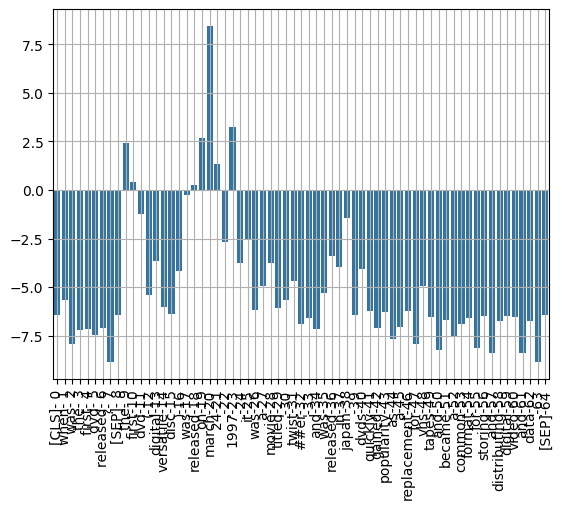

In [20]:
ax=sns.barplot(x=token_labels,y=s_scores)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90,ha="center")
ax.grid(True)

/tmp/ipykernel_3166/362556729.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90,ha="center")


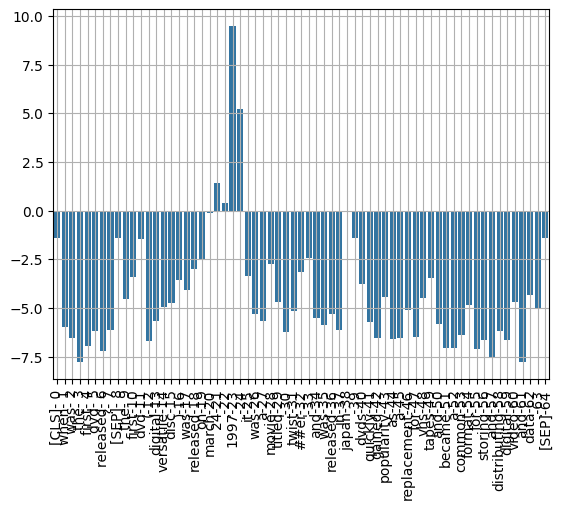

In [21]:
ax=sns.barplot(x=token_labels,y=e_scores)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90,ha="center")
ax.grid(True)

QUESTIONS ANSWERING

In [23]:
sunset_motors_context = "Sunset Motors is a renowned automobile dealership that has been a cornerstone of the automotive industry since its establishment in 1978. Located in the picturesque town of Crestwood, nestled in the heart of California's scenic Central Valley, Sunset Motors has built a reputation for excellence, reliability, and customer satisfaction over the past four decades. Founded by visionary entrepreneur Robert Anderson, Sunset Motors began as a humble, family-owned business with a small lot of used cars. However, under Anderson's leadership and commitment to quality, it quickly evolved into a thriving dealership offering a wide range of vehicles from various manufacturers. Today, the dealership spans over 10 acres, showcasing a vast inventory of new and pre-owned cars, trucks, SUVs, and luxury vehicles. One of Sunset Motors' standout features is its dedication to sustainability. In 2010, the dealership made a landmark decision to incorporate environmentally friendly practices, including solar panels to power the facility, energy-efficient lighting, and a comprehensive recycling program. This commitment to eco-consciousness has earned Sunset Motors recognition as an industry leader in sustainable automotive retail. Sunset Motors proudly offers a diverse range of vehicles, including popular brands like Ford, Toyota, Honda, Chevrolet, and BMW, catering to a wide spectrum of tastes and preferences. In addition to its outstanding vehicle selection, Sunset Motors offers flexible financing options, allowing customers to secure affordable loans and leases with competitive interest rates."
print(sunset_motors_context)

Sunset Motors is a renowned automobile dealership that has been a cornerstone of the automotive industry since its establishment in 1978. Located in the picturesque town of Crestwood, nestled in the heart of California's scenic Central Valley, Sunset Motors has built a reputation for excellence, reliability, and customer satisfaction over the past four decades. Founded by visionary entrepreneur Robert Anderson, Sunset Motors began as a humble, family-owned business with a small lot of used cars. However, under Anderson's leadership and commitment to quality, it quickly evolved into a thriving dealership offering a wide range of vehicles from various manufacturers. Today, the dealership spans over 10 acres, showcasing a vast inventory of new and pre-owned cars, trucks, SUVs, and luxury vehicles. One of Sunset Motors' standout features is its dedication to sustainability. In 2010, the dealership made a landmark decision to incorporate environmentally friendly practices, including solar p

In [42]:
def faq_bot(question):
  encoding=tokenizer(question,sunset_motors_context)
  input=encoding["input_ids"]
  token_type_ids=encoding["token_type_ids"]
  tokens=tokenizer.convert_ids_to_tokens(input)
  output=model(input_ids=torch.tensor([input]),token_type_ids=torch.tensor([token_type_ids]))
  start_index=torch.argmax(output.start_logits)
  end_index=torch.argmax(output.end_logits)
  answer=''
  if end_index>start_index:
    answer=" ".join(tokens[start_index:end_index+1])
  else:
    print("I don't know how to answer this question, can you ask another one?")
  corrected_answer=''
  for word in answer.split():
    if word[0:2]=="##":
      corrected_answer+=word[2:]
    else:
      corrected_answer+=" "+word
  return corrected_answer

In [43]:
answer=faq_bot("where is sunset motors located?")
print(answer)

 crestwood


In [45]:
faq_bot("what make of cars are available?")

' ford , toyota , honda , chevrolet , and bmw'

RoBERTA and DistilBERT

In [46]:
from transformers import RobertaTokenizer,RobertaModel
model_name="roberta-base"
tokenizer=RobertaTokenizer.from_pretrained(model_name)
model=RobertaModel.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [49]:
from transformers import DistilBertModel,DistilBertTokenizer
model_name="distilbert-base-uncased"
tokenizer=DistilBertTokenizer.from_pretrained(model_name)
model=DistilBertModel.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
